<a href="https://colab.research.google.com/github/Much1r1/AI-Engineering/blob/main/AI_Powered_Environmental_app_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# Setup and Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Setting the aesthetic for the environmental reports
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ AI Roadmap Phase 3: Environment Ready.")

✅ AI Roadmap Phase 3: Environment Ready.


In [11]:
# Data Ingestion
import zipfile
import io
import os

# Replace 'air_quality_2024.csv' with the exact name of your downloaded file
# The error indicates that the ZIP file contains multiple CSVs, and pandas.read_csv cannot handle that directly.
# To fix this, we need to specify which CSV file within the ZIP archive to read.
# Let's assume we want to read 'Air_Quality.csv' from the archive.

zip_file_path = '/content/archive.zip'
csv_file_in_zip = 'Air_Quality.csv'

try:
    # Check if the zip file exists
    if not os.path.exists(zip_file_path):
        raise FileNotFoundError(f"❌ Error: The zip file '{zip_file_path}' was not found. Please ensure it's uploaded.")

    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        file_list = zip_ref.namelist()
        print(f"Files found in {zip_file_path}: {file_list}")

        if csv_file_in_zip not in file_list:
            raise FileNotFoundError(f"❌ Error: '{csv_file_in_zip}' not found inside '{zip_file_path}'. Please check the filename or its casing.")

        # Read the specific CSV file from the zip archive into a BytesIO object
        with zip_ref.open(csv_file_in_zip) as csv_file:
            df_pollution = pd.read_csv(io.BytesIO(csv_file.read()))

    print("📋 Macro Data Summary:")
    print(df_pollution.info())
    display(df_pollution.head())

except FileNotFoundError as e:
    print(f"❌ Error: {e}. Please ensure the correct file name is specified and the dataset is uploaded to the correct path.")
except ValueError as e:
    print(f"❌ Error: {e}. This might occur if there are multiple files in the ZIP and the specific file was not correctly identified, or if the file format is not valid CSV.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Files found in /content/archive.zip: ['Air_Quality.csv', 'Brasilia_Air_Quality.csv', 'Cairo_Air_Quality.csv', 'Dubai_Air_Quality.csv', 'London_Air_Quality.csv', 'New_York_Air_Quality.csv', 'Sydney_Air_Quality.csv']
📋 Macro Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52704 entries, 0 to 52703
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    52704 non-null  object 
 1   City    52704 non-null  object 
 2   CO      52704 non-null  float64
 3   CO2     9648 non-null   float64
 4   NO2     52704 non-null  float64
 5   SO2     52704 non-null  float64
 6   O3      52704 non-null  float64
 7   PM2.5   52704 non-null  float64
 8   PM10    52704 non-null  float64
 9   AQI     52704 non-null  float64
dtypes: float64(8), object(2)
memory usage: 4.0+ MB
None


,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
0,2024-01-01 00:00:00+00:00,Brasilia,323.0,NaN,23.8,2.8,42.0,12.0,17.1,16.800000
1,2024-01-01 01:00:00+00:00,Brasilia,318.0,NaN,21.9,2.7,40.0,12.5,17.9,16.000000
2,2024-01-01 02:00:00+00:00,Brasilia,309.0,NaN,19.2,2.6,39.0,12.1,17.3,15.599999
3,2024-01-01 03:00:00+00:00,Brasilia,295.0,NaN,16.3,2.4,38.0,11.4,16.2,15.200000
4,2024-01-01 04:00:00+00:00,Brasilia,270.0,NaN,13.0,2.1,40.0,10.2,14.6,16.000000


In [12]:
# Time-Series Transformation (City-Specific)

# 1. Convert 'Date' to datetime objects
df_pollution['Date'] = pd.to_datetime(df_pollution['Date'])

# 2. Pick a city for the first model
target_city = "London"
df_city = df_pollution[df_pollution['City'] == target_city].copy()

# 3. Sort by Date
df_city = df_city.sort_values('Date')

# 4. Set Date as index (makes plotting and windowing much easier)
df_city.set_index('Date', inplace=True)

print(f"✅ Data isolated for {target_city}. Ready for sequence analysis.")
display(df_city.head())

✅ Data isolated for London. Ready for sequence analysis.


,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
Date,,,,,,,,,
2024-01-01 00:00:00+00:00,London,162.0,NaN,4.7,1.0,65.0,3.5,7.3,9.070833
2024-01-01 01:00:00+00:00,London,163.0,NaN,4.6,1.2,63.0,3.5,6.0,25.200000
2024-01-01 02:00:00+00:00,London,157.0,NaN,4.3,1.1,64.0,3.3,5.9,25.599998
2024-01-01 03:00:00+00:00,London,156.0,NaN,4.4,1.1,64.0,3.1,5.7,25.599998
2024-01-01 04:00:00+00:00,London,157.0,NaN,4.6,1.1,65.0,2.9,5.7,26.000000


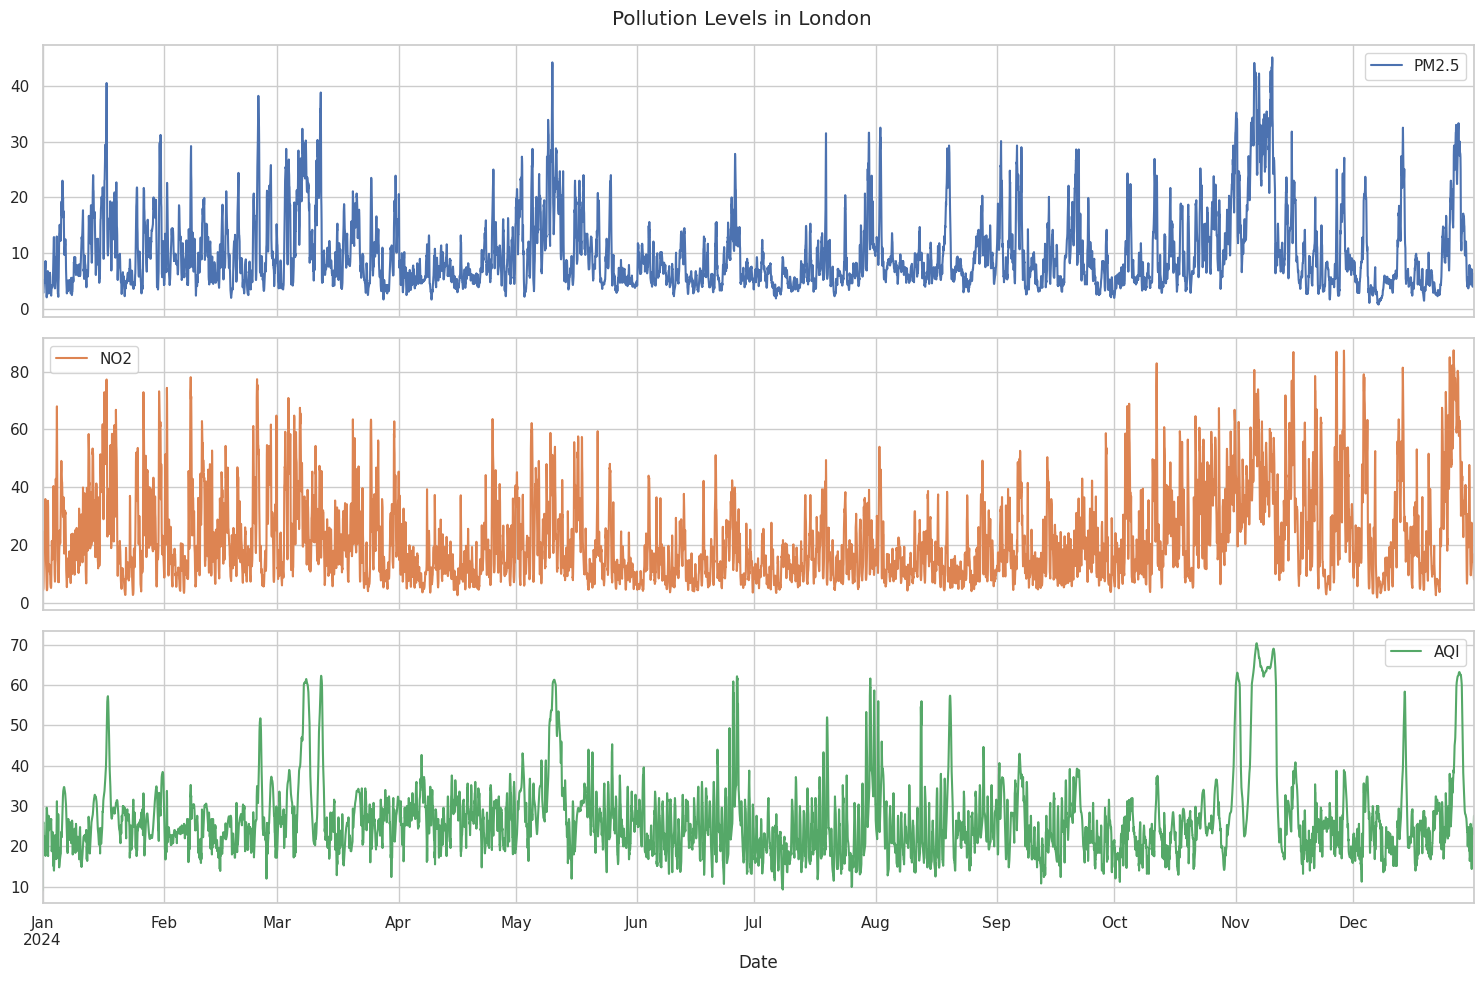

🔍 AI Strategy: We will train the model to look at the relationship between NO2 (Traffic) and AQI (Overall health).


In [13]:
# Multi-Pollutant Visualization
cols_to_plot = ['PM2.5', 'NO2', 'AQI']
df_city[cols_to_plot].plot(subplots=True, figsize=(15, 10), title=f'Pollution Levels in {target_city}')

plt.xlabel('Date')
plt.tight_layout()
plt.show()

print("🔍 AI Strategy: We will train the model to look at the relationship between NO2 (Traffic) and AQI (Overall health).")

In [14]:
# Data Scaling (Normalization)
from sklearn.preprocessing import MinMaxScaler

# AQI for the first prediction model
data_to_scale = df_city[['AQI']].values

# Initialize Scaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_to_scale)

print(f"✅ Data normalized. Range: {scaled_data.min()} to {scaled_data.max()}")

✅ Data normalized. Range: 0.0 to 1.0


In [15]:
# Sliding Window Function
def create_sequences(data, window_size):
    X = []
    y = []
    for i in range(window_size, len(data)):
        # X: The past 'window_size' steps
        X.append(data[i-window_size:i, 0])
        # y: The current step (what we want to predict)
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Using the past 24 hours to predict the next 1 hour
WINDOW_SIZE = 24
X, y = create_sequences(scaled_data, WINDOW_SIZE)

# Reshape X to 3D [samples, time steps, features] for the LSTM
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print(f"📊 Training Data Shape: {X.shape}")
print(f"🎯 Target Data Shape: {y.shape}")

📊 Training Data Shape: (8760, 24, 1)
🎯 Target Data Shape: (8760,)


In [16]:
# Chronological Split (80% Train, 20% Test)
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"✅ Split complete. Training on {len(X_train)} hours, Testing on {len(X_test)} hours.")

✅ Split complete. Training on 7008 hours, Testing on 1752 hours.


In [17]:
# LSTM Model Architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    # First LSTM layer: 50 units
    # return_sequences=True is only used if stacking another LSTM layer
    LSTM(units=50, activation='relu', input_shape=(X_train.shape[1], 1)),
    Dropout(0.2), # Randomly turns off 20% of neurons to prevent overfitting

    # Final Output Layer: Predicts a single value (the next hour's AQI)
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()
print("✅ Neural Network compiled. Ready for the training grind.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

✅ Neural Network compiled. Ready for the training grind.


In [18]:
# Model Training
# Using a validation split to watch the AI test itself as it learns
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

print("🚀 Training complete! The Sentinel has finished its first simulation.")

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0240 - val_loss: 0.0036
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0062 - val_loss: 0.0025
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0046 - val_loss: 0.0019
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0036 - val_loss: 0.0016
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0031 - val_loss: 0.0015
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0028 - val_loss: 0.0016
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0024 - val_loss: 0.0013
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0021 - val_loss: 0.0012
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0021 - val_loss: 0.0011
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0020 - val_loss: 9.5337e-04
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0018 - val_loss: 8.8947e-04
Epoch 12/20
219/219 ━━━━━━━━━━━━━

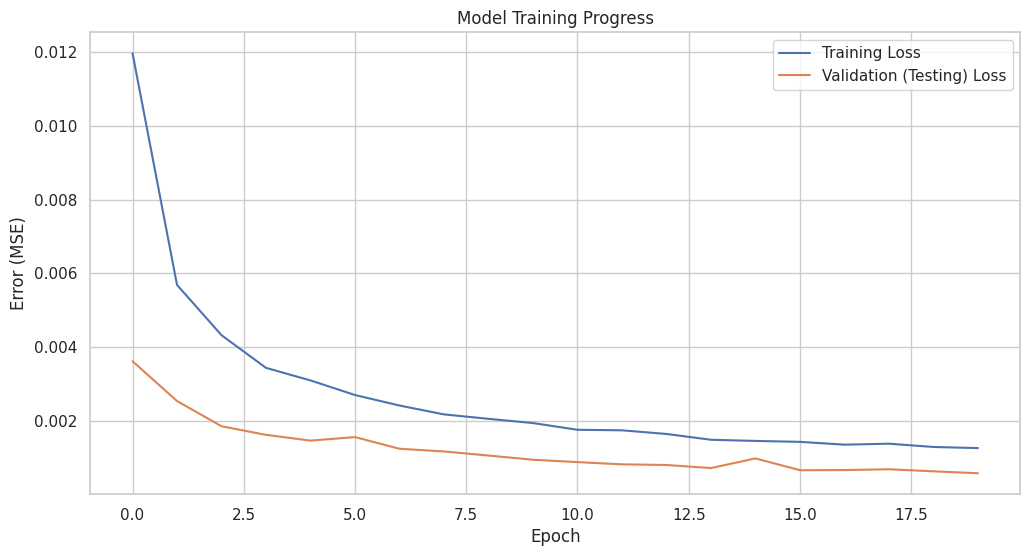

In [19]:
# Loss Visualization
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation (Testing) Loss')
plt.title('Model Training Progress')
plt.ylabel('Error (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [20]:
# Inverse Transform & Prediction
# 1. Get predictions for the test set
predictions = model.predict(X_test)

# 2. Invert the scaling for both predictions and actual targets
# Since the scaler was fit on a single feature (AQI), use it directly
y_pred_rescaled = scaler.inverse_transform(predictions)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

print("✅ Predictions converted back to original AQI units.")

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
✅ Predictions converted back to original AQI units.


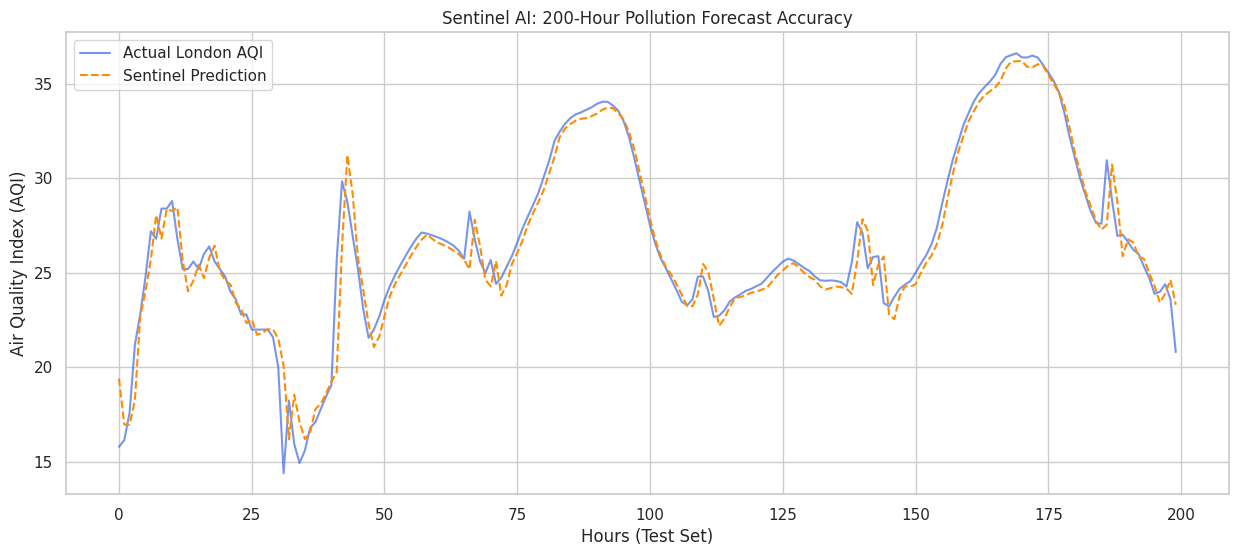

📊 Model Precision: The Sentinel's average error is 1.49 AQI points.


In [21]:
# Forecasting Performance Visualization
plt.figure(figsize=(15, 6))
plt.plot(y_test_rescaled[:200], label='Actual London AQI', color='royalblue', alpha=0.7)
plt.plot(y_pred_rescaled[:200], label='Sentinel Prediction', color='darkorange', linestyle='--')

plt.title('Sentinel AI: 200-Hour Pollution Forecast Accuracy')
plt.xlabel('Hours (Test Set)')
plt.ylabel('Air Quality Index (AQI)')
plt.legend()
plt.show()

# Calculate the Error (Root Mean Squared Error)
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
print(f"📊 Model Precision: The Sentinel's average error is {rmse:.2f} AQI points.")

In [22]:
# Extracting and Loading User Behavior Data
import zipfile
import os
import pandas as pd

zip_path = '/content/archive (1).zip'
extract_path = '/content/Environmental-Impact-Analyzer/data/user_behavior'

# 1. Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# 2. List files and load the main CSV
extracted_files = os.listdir(extract_path)
print(f"📂 Files extracted: {extracted_files}")

data_file = [f for f in extracted_files if f.endswith('.csv')][0]
df_user = pd.read_csv(os.path.join(extract_path, data_file))

print("👤 User Behavior Data Loaded:")
display(df_user.head())

📂 Files extracted: ['personal_carbon_footprint_behavior.csv']
👤 User Behavior Data Loaded:


,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
0,1,Weekend,EV,1.55,6.12,0,Non-Veg,2.4,0.70,1,11.03,High
1,1,Weekend,Walk,10.04,4.50,0,Mixed,4.1,0.54,1,7.44,Medium
2,1,Weekday,Walk,15.27,2.81,0,Mixed,4.0,0.51,1,6.01,Medium
3,1,Weekend,Walk,0.50,10.16,0,Mixed,6.3,0.73,0,12.70,High
4,1,Weekend,Walk,3.60,5.02,50,Mixed,5.1,0.64,0,6.33,Medium


In [23]:
# Preprocessing for the Micro-Tracker
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Drop the ID - it's just a label, not a feature
df_micro = df_user.drop(columns=['user_id'])

# 2. Encode categorical columns
le = LabelEncoder()
cat_cols = ['day_type', 'transport_mode', 'food_type', 'eco_actions', 'carbon_impact_level']

for col in cat_cols:
    df_micro[col] = le.fit_transform(df_micro[col])

# 3. Define Features (X) and Target (y)
# Predict the 'carbon_impact_level' (High, Medium, Low)
X_micro = df_micro.drop(columns=['carbon_impact_level', 'carbon_footprint_kg'])
y_micro = df_micro['carbon_impact_level']

# 4. Split the data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_micro, y_micro, test_size=0.2, random_state=42)

print(f"✅ Micro-data ready. Features: {list(X_micro.columns)}")

✅ Micro-data ready. Features: ['day_type', 'transport_mode', 'distance_km', 'electricity_kwh', 'renewable_usage_pct', 'food_type', 'screen_time_hours', 'waste_generated_kg', 'eco_actions']


In [24]:
# Random Forest Training
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the "Behavioral Brain"
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_m, y_train_m)

# Test the model
y_pred_m = rf_model.predict(X_test_m)

print("🎯 Behavioral Classification Report:")
print(classification_report(y_test_m, y_pred_m))

🎯 Behavioral Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.63      0.74        46
           1       0.90      0.77      0.83        73
           2       0.82      0.94      0.88       161

    accuracy                           0.85       280
   macro avg       0.88      0.78      0.82       280
weighted avg       0.85      0.85      0.84       280



/tmp/ipykernel_416/3629475511.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


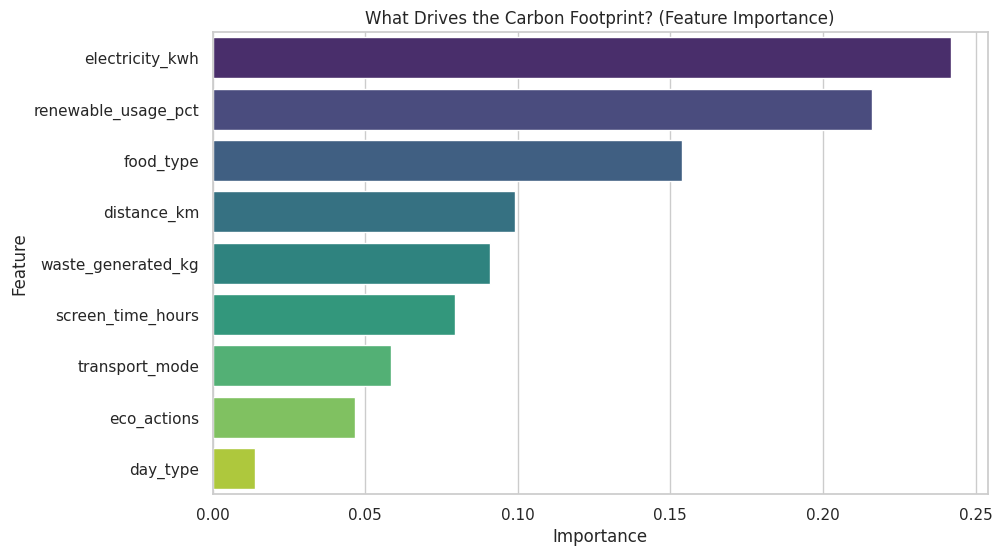

📋 Top Impact Driver: electricity_kwh


In [25]:
# Feature Importance Ranking
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_model.feature_importances_
feature_names = X_micro.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualize the impact drivers
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('What Drives the Carbon Footprint? (Feature Importance)')
plt.show()

print("📋 Top Impact Driver:", feature_importance_df.iloc[0]['Feature'])

In [26]:
# Unified Inference Function
def get_environmental_report(user_input_data, aqi_forecast):
    # 1. Predict User Impact Level
    # user_input_data should be a processed row/list
    impact_code = rf_model.predict([user_input_data])[0]
    impact_labels = {0: 'High', 1: 'Medium', 2: 'Low'}
    user_impact = impact_labels[impact_code]

    # 2. Logic for Recommendation
    recommendation = ""
    if aqi_forecast > 100:
        if user_impact == 'High':
            recommendation = "🚨 ALERT: High City Pollution & High Personal Impact. Immediate reduction in driving/energy suggested."
        else:
            recommendation = "⚠️ WARNING: High City Pollution. Your impact is low, but avoid outdoor exercise today."
    else:
        recommendation = "✅ City air is clear. Continue your green habits!"

    return f"User Status: {user_impact} Impact | Recommendation: {recommendation}"

# Example Test: (Passing dummy encoded data)
test_user = [1, 2, 10.5, 45.0, 10, 1, 3.5, 0.6, 1] # Mock features
print(get_environmental_report(test_user, aqi_forecast=120))

User Status: High Impact | Recommendation: 🚨 ALERT: High City Pollution & High Personal Impact. Immediate reduction in driving/energy suggested.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [27]:
# Saving Preprocessing Assets
import joblib
import os

# Create the directory structure
paths = [
    'Environmental-Impact-Analyzer/models/scalers',
    'Environmental-Impact-Analyzer/data/processed'
]
for path in paths:
    os.makedirs(path, exist_ok=True)

# 1. Save the Time-Series Scaler (for the Sentinel)
joblib.dump(scaler, 'Environmental-Impact-Analyzer/models/scalers/aqi_scaler.pkl')

# 2. Save the Behavioral Encoders (for the Tracker)
joblib.dump(le, 'Environmental-Impact-Analyzer/models/scalers/behavior_encoder.pkl')

# 3. Save the actual trained models
model.save('Environmental-Impact-Analyzer/models/sentinel_lstm.keras')
joblib.dump(rf_model, 'Environmental-Impact-Analyzer/models/carbon_tracker_rf.pkl')

print("✅ Portfolio assets secured in professional directory structure.")

✅ Portfolio assets secured in professional directory structure.
